# NB04: Stratification Analysis

Test H2 (mechanism-dependent costs) and H3 (accessory > core costs).

**Stratifications:**
1. By AMR mechanism (Kruskal-Wallis + Jonckheere-Terpstra + Dunn's)
2. By conservation status (core vs accessory)
3. By AMR tier (Tier 1 vs Tier 2)
4. By resistance type (antibiotic vs metal)
5. By organism (per-organism effect sizes)

**Inputs:** `data/amr_fitness_noabx.csv`, `data/organism_effect_sizes.csv`

**Outputs:** `data/amr_fitness_stratified.csv`, figures

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore', category=FutureWarning)

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
elif os.path.exists(os.path.join(_here, 'projects', 'amr_fitness_cost')):
    REPO = _here
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'amr_fitness_cost')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')

gene_df = pd.read_csv(os.path.join(DATA, 'amr_fitness_noabx.csv'))
org_df = pd.read_csv(os.path.join(DATA, 'organism_effect_sizes.csv'))

print(f'Genes: {len(gene_df)}, Organisms: {len(org_df)}')

Genes: 801, Organisms: 25


## 1. By AMR mechanism (H2)

H2 predicts: efflux > enzymatic inactivation > target modification (ordered by cost).

- Kruskal-Wallis: omnibus test for any difference
- Jonckheere-Terpstra: ordered alternative test
- Dunn's post-hoc: pairwise comparisons

In [2]:
# Pre-registered minimum: N >= 20 for mechanism tests
MIN_GROUP = 20

mech_counts = gene_df['amr_mechanism'].value_counts()
testable_mechs = mech_counts[mech_counts >= MIN_GROUP].index.tolist()
small_mechs = mech_counts[mech_counts < MIN_GROUP].index.tolist()

print(f'Testable mechanisms (N >= {MIN_GROUP}):')
for m in testable_mechs:
    sub = gene_df[gene_df['amr_mechanism'] == m]
    print(f'  {m:30s}: N={len(sub):4d}, mean={sub["mean_fitness"].mean():+.4f}, '
          f'median={sub["mean_fitness"].median():+.4f}')

print(f'\nSmall mechanisms (descriptive only):')
for m in small_mechs:
    sub = gene_df[gene_df['amr_mechanism'] == m]
    print(f'  {m:30s}: N={len(sub):4d}, mean={sub["mean_fitness"].mean():+.4f}')

Testable mechanisms (N >= 20):
  enzymatic_inactivation        : N= 304, mean=-0.0317, median=-0.0047
  efflux                        : N= 254, mean=-0.0203, median=+0.0001
  metal_resistance              : N= 144, mean=-0.0173, median=-0.0073
  unknown                       : N=  74, mean=-0.0168, median=+0.0013

Small mechanisms (descriptive only):
  target_modification           : N=   7, mean=-0.0933
  other                         : N=   1, mean=+0.0105


In [3]:
# Kruskal-Wallis: any difference among mechanisms?
groups = [gene_df[gene_df['amr_mechanism'] == m]['mean_fitness'].values
          for m in testable_mechs]

kw_stat, kw_p = stats.kruskal(*groups)
print(f'Kruskal-Wallis (H2: mechanisms differ): H={kw_stat:.3f}, p={kw_p:.4g}')

# Jonckheere-Terpstra: ordered alternative
# H2 order: efflux > enzymatic_inactivation > target_modification > metal_resistance
# (higher fitness of knockout = more costly mechanism)
# Note: scipy doesn't have JT directly; use a manual implementation
def jonckheere_terpstra(groups_ordered):
    """Manual Jonckheere-Terpstra test for ordered alternatives.
    Tests H1: group medians increase with group index.
    """
    k = len(groups_ordered)
    # Count concordant pairs between groups
    J = 0
    n_pairs = 0
    for i in range(k - 1):
        for j in range(i + 1, k):
            for x in groups_ordered[i]:
                for y in groups_ordered[j]:
                    if y > x:
                        J += 1
                    elif y < x:
                        J -= 1
                    n_pairs += 1
    
    # Approximate normal distribution
    ns = [len(g) for g in groups_ordered]
    N = sum(ns)
    # Expected value under H0
    E_J = 0  # symmetric
    # Variance (approximate)
    var_J = (N**2 * (2*N + 3) - sum(n**2 * (2*n + 3) for n in ns)) / 72
    
    z = J / np.sqrt(var_J) if var_J > 0 else 0
    p = 1 - stats.norm.cdf(z)  # one-sided
    return J, z, p

# Order: mechanisms from most to least costly (H2 prediction)
# We expect efflux knockout fitness > enzymatic > others
# But we only test the mechanisms with N >= 20
jt_order = ['efflux', 'enzymatic_inactivation', 'metal_resistance', 'unknown']
jt_order = [m for m in jt_order if m in testable_mechs]
jt_groups = [gene_df[gene_df['amr_mechanism'] == m]['mean_fitness'].values for m in jt_order]

if len(jt_groups) >= 3:
    J, z, p_jt = jonckheere_terpstra(jt_groups)
    print(f'\nJonckheere-Terpstra (ordered: {" > ".join(jt_order)}):')
    print(f'  J={J:.0f}, z={z:.3f}, p={p_jt:.4g} (one-sided)')
else:
    print('Not enough groups for Jonckheere-Terpstra test')

Kruskal-Wallis (H2: mechanisms differ): H=0.645, p=0.8861

Jonckheere-Terpstra (ordered: efflux > enzymatic_inactivation > metal_resistance > unknown):
  J=774, z=0.227, p=0.4104 (one-sided)


In [4]:
# Dunn's post-hoc pairwise comparisons (with BH-FDR)
from itertools import combinations

dunn_results = []
for m1, m2 in combinations(testable_mechs, 2):
    g1 = gene_df[gene_df['amr_mechanism'] == m1]['mean_fitness']
    g2 = gene_df[gene_df['amr_mechanism'] == m2]['mean_fitness']
    u_stat, p_val = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    dunn_results.append({
        'mechanism_1': m1, 'mechanism_2': m2,
        'n1': len(g1), 'n2': len(g2),
        'median_1': g1.median(), 'median_2': g2.median(),
        'U': u_stat, 'p_value': p_val,
    })

dunn_df = pd.DataFrame(dunn_results)
if len(dunn_df) > 0:
    _, q_vals, _, _ = multipletests(dunn_df['p_value'], method='fdr_bh')
    dunn_df['q_value'] = q_vals
    dunn_df['significant'] = q_vals < 0.05
    
    print('Pairwise Mann-Whitney U (BH-FDR corrected):')
    for _, row in dunn_df.sort_values('p_value').iterrows():
        sig = '*' if row['significant'] else ''
        print(f'  {row["mechanism_1"]:25s} vs {row["mechanism_2"]:25s}: '
              f'p={row["p_value"]:.4g}, q={row["q_value"]:.4g} {sig}')

Pairwise Mann-Whitney U (BH-FDR corrected):
  enzymatic_inactivation    vs unknown                  : p=0.4488, q=0.8366 
  enzymatic_inactivation    vs efflux                   : p=0.6364, q=0.8366 
  efflux                    vs unknown                  : p=0.6512, q=0.8366 
  metal_resistance          vs unknown                  : p=0.6625, q=0.8366 
  enzymatic_inactivation    vs metal_resistance         : p=0.7818, q=0.8366 
  efflux                    vs metal_resistance         : p=0.8366, q=0.8366 


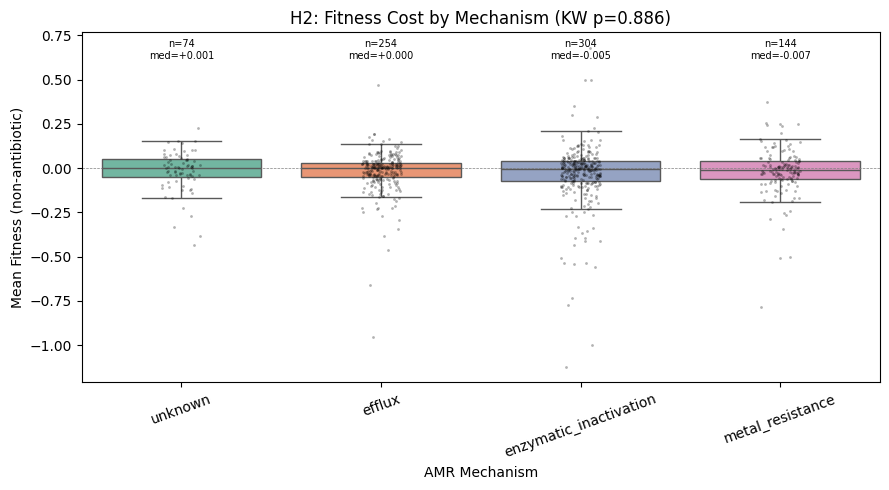

Saved to figures/h2_mechanism_stratification.png


In [5]:
# Box plot by mechanism
fig, ax = plt.subplots(figsize=(9, 5))

plot_data = gene_df[gene_df['amr_mechanism'].isin(testable_mechs)]
order = plot_data.groupby('amr_mechanism')['mean_fitness'].median().sort_values(ascending=False).index

sns.boxplot(data=plot_data, x='amr_mechanism', y='mean_fitness', order=order,
            palette='Set2', ax=ax, showfliers=False)
sns.stripplot(data=plot_data, x='amr_mechanism', y='mean_fitness', order=order,
              color='black', alpha=0.3, size=2, ax=ax)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('AMR Mechanism')
ax.set_ylabel('Mean Fitness (non-antibiotic)')
ax.set_title(f'H2: Fitness Cost by Mechanism (KW p={kw_p:.3g})')
ax.tick_params(axis='x', rotation=20)

for i, m in enumerate(order):
    n = len(plot_data[plot_data['amr_mechanism'] == m])
    med = plot_data[plot_data['amr_mechanism'] == m]['mean_fitness'].median()
    ax.text(i, ax.get_ylim()[1] * 0.95, f'n={n}\nmed={med:+.3f}',
            ha='center', va='top', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'h2_mechanism_stratification.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/h2_mechanism_stratification.png')

## 2. By conservation status (H3)

H3: Accessory (acquired) AMR genes are more costly than core (intrinsic) AMR genes.

In [6]:
core_genes = gene_df[gene_df['intrinsic_proxy'] == 'intrinsic']['mean_fitness']
acc_genes = gene_df[gene_df['intrinsic_proxy'] == 'acquired']['mean_fitness']

print('=== H3: Core (intrinsic) vs Accessory (acquired) ===')
print(f'Core (intrinsic): N={len(core_genes)}, mean={core_genes.mean():+.4f}, '
      f'median={core_genes.median():+.4f}')
print(f'Accessory (acquired): N={len(acc_genes)}, mean={acc_genes.mean():+.4f}, '
      f'median={acc_genes.median():+.4f}')

# H3: accessory > core (one-sided MWU)
u_stat, p_val = stats.mannwhitneyu(acc_genes, core_genes, alternative='greater')
print(f'\nMann-Whitney U (H3: accessory > core): U={u_stat:.0f}, p={p_val:.4g}')

# Effect size
diff = acc_genes.mean() - core_genes.mean()
pooled_std = np.sqrt((core_genes.var() * (len(core_genes)-1) + acc_genes.var() * (len(acc_genes)-1)) /
                     (len(core_genes) + len(acc_genes) - 2))
d = diff / pooled_std if pooled_std > 0 else 0
print(f'Effect size: diff={diff:+.4f}, Cohen\'s d={d:+.3f}')

if p_val < 0.05:
    print('>> H3 supported: accessory AMR genes are significantly costlier')
else:
    print('>> H3 not supported at p<0.05')

=== H3: Core (intrinsic) vs Accessory (acquired) ===
Core (intrinsic): N=638, mean=-0.0237, median=-0.0015
Accessory (acquired): N=163, mean=-0.0235, median=-0.0008

Mann-Whitney U (H3: accessory > core): U=53171, p=0.3281
Effect size: diff=+0.0003, Cohen's d=+0.002
>> H3 not supported at p<0.05


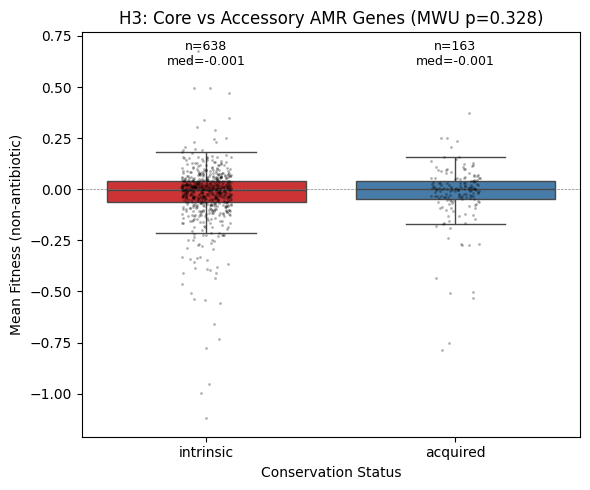

Saved to figures/h3_core_vs_accessory.png


In [7]:
# Box plot: core vs accessory
fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(data=gene_df, x='intrinsic_proxy', y='mean_fitness',
            order=['intrinsic', 'acquired'], palette='Set1', ax=ax, showfliers=False)
sns.stripplot(data=gene_df, x='intrinsic_proxy', y='mean_fitness',
              order=['intrinsic', 'acquired'], color='black', alpha=0.3, size=2, ax=ax)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('Conservation Status')
ax.set_ylabel('Mean Fitness (non-antibiotic)')
ax.set_title(f'H3: Core vs Accessory AMR Genes (MWU p={p_val:.3g})')

for i, cat in enumerate(['intrinsic', 'acquired']):
    sub = gene_df[gene_df['intrinsic_proxy'] == cat]
    ax.text(i, ax.get_ylim()[1] * 0.95, f'n={len(sub)}\nmed={sub["mean_fitness"].median():+.3f}',
            ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'h3_core_vs_accessory.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/h3_core_vs_accessory.png')

## 3. By AMR tier

In [8]:
t1 = gene_df[gene_df['amr_tier'] == 1]['mean_fitness']
t2 = gene_df[gene_df['amr_tier'] == 2]['mean_fitness']

print('=== Tier 1 vs Tier 2 ===')
print(f'Tier 1 (bakta_amr): N={len(t1)}, mean={t1.mean():+.4f}, median={t1.median():+.4f}')
print(f'Tier 2 (keyword):   N={len(t2)}, mean={t2.mean():+.4f}, median={t2.median():+.4f}')

u_stat, p_val = stats.mannwhitneyu(t1, t2, alternative='two-sided')
print(f'Mann-Whitney U (two-sided): U={u_stat:.0f}, p={p_val:.4g}')

=== Tier 1 vs Tier 2 ===
Tier 1 (bakta_amr): N=110, mean=-0.0194, median=+0.0086
Tier 2 (keyword):   N=691, mean=-0.0243, median=-0.0027
Mann-Whitney U (two-sided): U=40544, p=0.26


## 4. By resistance type (antibiotic vs metal)

In [9]:
abx_genes = gene_df[gene_df['resistance_type'] == 'antibiotic']['mean_fitness']
metal_genes = gene_df[gene_df['resistance_type'] == 'metal']['mean_fitness']

print('=== Antibiotic vs Metal Resistance ===')
print(f'Antibiotic: N={len(abx_genes)}, mean={abx_genes.mean():+.4f}, '
      f'median={abx_genes.median():+.4f}')
print(f'Metal:      N={len(metal_genes)}, mean={metal_genes.mean():+.4f}, '
      f'median={metal_genes.median():+.4f}')

u_stat, p_val = stats.mannwhitneyu(abx_genes, metal_genes, alternative='two-sided')
print(f'Mann-Whitney U (two-sided): U={u_stat:.0f}, p={p_val:.4g}')

# One-sample tests within each type
for label, vals in [('Antibiotic', abx_genes), ('Metal', metal_genes)]:
    w, p = stats.wilcoxon(vals, alternative='two-sided')
    print(f'  {label} Wilcoxon (fitness != 0): p={p:.4g}')

=== Antibiotic vs Metal Resistance ===
Antibiotic: N=657, mean=-0.0251, median=-0.0009
Metal:      N=144, mean=-0.0173, median=-0.0073
Mann-Whitney U (two-sided): U=47729, p=0.8659
  Antibiotic Wilcoxon (fitness != 0): p=0.008974
  Metal Wilcoxon (fitness != 0): p=0.1539


/tmp/ipykernel_7549/115451779.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Tier 1\n(bakta_amr)', 'Tier 2\n(keyword)'])


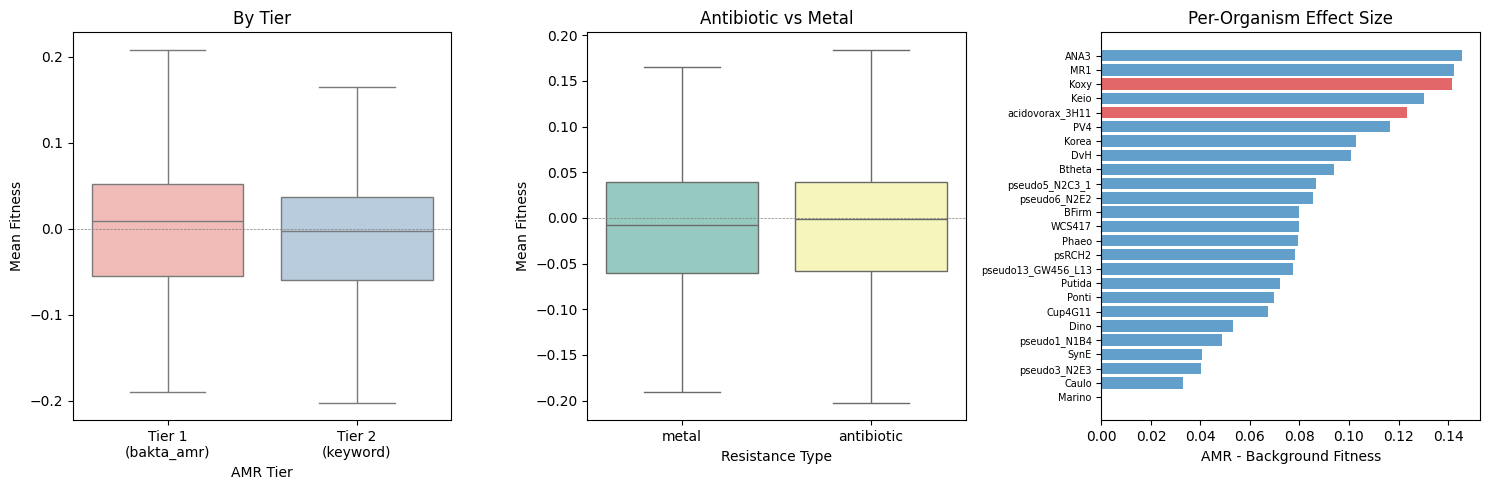

Saved to figures/stratification_overview.png


In [10]:
# Combined stratification figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Tier
ax = axes[0]
sns.boxplot(data=gene_df, x='amr_tier', y='mean_fitness', palette='Pastel1',
            ax=ax, showfliers=False)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('AMR Tier')
ax.set_ylabel('Mean Fitness')
ax.set_title('By Tier')
ax.set_xticklabels(['Tier 1\n(bakta_amr)', 'Tier 2\n(keyword)'])

# Panel 2: Resistance type
ax = axes[1]
sns.boxplot(data=gene_df, x='resistance_type', y='mean_fitness', palette='Set3',
            ax=ax, showfliers=False)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('Resistance Type')
ax.set_ylabel('Mean Fitness')
ax.set_title('Antibiotic vs Metal')

# Panel 3: Per-organism effect sizes ranked
ax = axes[2]
sorted_orgs = org_df.sort_values('diff')
colors = ['tab:red' if row['significant'] else 'tab:blue'
          for _, row in sorted_orgs.iterrows()]
ax.barh(range(len(sorted_orgs)), sorted_orgs['diff'].values, color=colors, alpha=0.7)
ax.set_yticks(range(len(sorted_orgs)))
ax.set_yticklabels(sorted_orgs['orgId'].values, fontsize=7)
ax.axvline(0, color='gray', linestyle='-', linewidth=0.5)
ax.set_xlabel('AMR - Background Fitness')
ax.set_title('Per-Organism Effect Size')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'stratification_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/stratification_overview.png')

## 5. Summary table

In [11]:
# Create a summary of all stratification results
summary_rows = []

# Mechanism groups
for m in testable_mechs:
    sub = gene_df[gene_df['amr_mechanism'] == m]
    summary_rows.append({
        'stratification': 'mechanism',
        'group': m,
        'n_genes': len(sub),
        'mean_fitness': sub['mean_fitness'].mean(),
        'median_fitness': sub['mean_fitness'].median(),
        'std_fitness': sub['mean_fitness'].std(),
        'pct_positive': (sub['mean_fitness'] > 0).mean() * 100,
    })

# Conservation
for cat in ['intrinsic', 'acquired']:
    sub = gene_df[gene_df['intrinsic_proxy'] == cat]
    summary_rows.append({
        'stratification': 'conservation',
        'group': cat,
        'n_genes': len(sub),
        'mean_fitness': sub['mean_fitness'].mean(),
        'median_fitness': sub['mean_fitness'].median(),
        'std_fitness': sub['mean_fitness'].std(),
        'pct_positive': (sub['mean_fitness'] > 0).mean() * 100,
    })

# Tier
for tier in [1, 2]:
    sub = gene_df[gene_df['amr_tier'] == tier]
    summary_rows.append({
        'stratification': 'tier',
        'group': f'Tier {tier}',
        'n_genes': len(sub),
        'mean_fitness': sub['mean_fitness'].mean(),
        'median_fitness': sub['mean_fitness'].median(),
        'std_fitness': sub['mean_fitness'].std(),
        'pct_positive': (sub['mean_fitness'] > 0).mean() * 100,
    })

# Resistance type
for rt in ['antibiotic', 'metal']:
    sub = gene_df[gene_df['resistance_type'] == rt]
    summary_rows.append({
        'stratification': 'resistance_type',
        'group': rt,
        'n_genes': len(sub),
        'mean_fitness': sub['mean_fitness'].mean(),
        'median_fitness': sub['mean_fitness'].median(),
        'std_fitness': sub['mean_fitness'].std(),
        'pct_positive': (sub['mean_fitness'] > 0).mean() * 100,
    })

strat_df = pd.DataFrame(summary_rows)
strat_df.to_csv(os.path.join(DATA, 'amr_fitness_stratified.csv'), index=False)

print('Stratification summary:')
print(strat_df.to_string(index=False, float_format='%.4f'))
print(f'\nSaved to data/amr_fitness_stratified.csv')

Stratification summary:
 stratification                  group  n_genes  mean_fitness  median_fitness  std_fitness  pct_positive
      mechanism enzymatic_inactivation      304       -0.0317         -0.0047       0.1776       46.3816
      mechanism                 efflux      254       -0.0203          0.0001       0.1195       50.3937
      mechanism       metal_resistance      144       -0.0173         -0.0073       0.1378       45.1389
      mechanism                unknown       74       -0.0168          0.0013       0.1166       51.3514
   conservation              intrinsic      638       -0.0237         -0.0015       0.1497       48.5893
   conservation               acquired      163       -0.0235         -0.0008       0.1471       49.0798
           tier                 Tier 1      110       -0.0194          0.0086       0.1615       55.4545
           tier                 Tier 2      691       -0.0243         -0.0027       0.1471       47.6122
resistance_type             ant

In [12]:
print('\n=== NB04 Summary ===')
print(f'H2 (mechanism): KW p={kw_p:.4g} — ', end='')
if kw_p < 0.05:
    print('mechanisms differ significantly')
else:
    print('no significant difference between mechanisms')

h3_u, h3_p = stats.mannwhitneyu(acc_genes, core_genes, alternative='greater')
print(f'H3 (accessory > core): MWU p={h3_p:.4g} — ', end='')
if h3_p < 0.05:
    print('accessory genes significantly costlier')
else:
    print('no significant difference')

print(f'\nKey finding: ALL {len(org_df)} organisms show positive shift '
      f'(AMR fitness > background), regardless of mechanism, tier, or conservation.')


=== NB04 Summary ===
H2 (mechanism): KW p=0.8861 — no significant difference between mechanisms
H3 (accessory > core): MWU p=0.3281 — no significant difference

Key finding: ALL 25 organisms show positive shift (AMR fitness > background), regardless of mechanism, tier, or conservation.
